<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/01_Clasificación_Bayesiana/kde.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [103]:
#########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)              #
# E-mail: wgomez@cinvestav.mx                           #
# Curso:   Análisis de datos                            #
# Tópico:  kernel density estimation (KDE)              #
#########################################################

Carga bibliotecas necesarias

In [104]:
import numpy as np
from scipy.stats import norm, iqr
import matplotlib.pyplot as plt

Función principal para la estimación de densidad de kernel

In [105]:
def kde(x, xh, opt):
    # Cálculo del tamaño de ventana h
    if opt.lower() == 'dpi': # Regla de plug-in directa
        h = dpi(x)
    elif opt.lower() == 'sil1': # Regla de Silverman original
        h = ((4 * np.std(x, ddof=1)**5) / (3 * len(x)))**(1/5)
    elif opt.lower() == 'sil2': # Regla de Silverman modificafa
        h = 0.9 * min(np.std(x, ddof=1), iqr(x) / 1.34) * len(x)**(-1/5)
    m = len(xh)
    phi = lambda u: np.exp(-0.5 * (u**2)) / np.sqrt(2 * np.pi)  # kernel Gaussiano
    ph = np.zeros(m)
    for j in range(m):
        ph[j] = np.mean(phi((xh[j] - x) / h) / h) # Calcula la densidad en cada punto de la retícula
    return ph, h

Función para el cálculo del tamaño de ventana usando la regla plug-in directa

In [106]:
def psi_r(dKr, r, g, xij, n):
    xij_scaled = xij / g
    S = np.sum(dKr(xij_scaled.ravel()))
    Psi = (n * (n - 1))**(-1) * g**(-r - 1) * S  # Sheather and Jones (1991) p. 689
    return Psi

def dpi(xi):
    # derivadas del kernel Gaussiano
    dK4 = lambda x: np.exp(x**2 * (-1.0 / 2.0)) * 1.196826841204298 - x**2 * np.exp(x**2 * (-1.0 / 2.0)) * 2.393653682408596 + x**4 * np.exp(x**2 * (-1.0 / 2.0)) * 3.989422804014327e-1
    dK6 = lambda x: np.exp(x**2 * (-1.0 / 2.0)) * (-5.984134206021491) + x**2 * np.exp(x**2 * (-1.0 / 2.0)) * 1.795240261806447e1 - x**4 * np.exp(x**2 * (-1.0 / 2.0)) * 5.984134206021491 + x**6 * np.exp(x**2 * (-1.0 / 2.0)) * 3.989422804014327e-1
    # Numero de puntos
    n = len(xi)
    # Diferencia entre cada par de puntos
    xi_flat = xi.flatten()
    xij = xi_flat[:, np.newaxis] - xi_flat[np.newaxis, :]
    # Algoritmo de Wand and Jones (1995) p. 72
    # Paso 1: Estimar psi_8 usando la formula hat_psi_8^NS
    # Psi8_NS = 105/(32*pi^0.5*std(xi)^9);
    mad_val = np.mean(np.abs(xi - np.mean(xi)))
    Psi8_NS = 105 / (32 * np.sqrt(np.pi) * mad_val**9)
    # Paso 2: Estimar psi_6 usando el estimador hat_psi_6(g1)
    g1 = (11.9683 / (Psi8_NS * n))**(1/9)
    Psi_6 = psi_r(dK6, 6, g1, xij, n)
    # Paso 3: Estimar psi_4 usando el estimador hat_psi_4(g2)
    g2 = (-2.3937 / (Psi_6 * n))**(1/7)
    Psi_4 = psi_r(dK4, 4, g2, xij, n)
    # Paso 4: calcular el ancho de banda h
    h = (0.2821 / (Psi_4 * n))**(1/5)
    return h

Distancia de Hellinger para comparar dos PDFs $f(x)$ y $g(x)$
\begin{equation}
{H^2}\left( {f,g} \right) = \frac{1}{2}\int {{{\left( {\sqrt {f(x)}  - \sqrt {g(x)} } \right)}^2}dx}
\end{equation}

In [107]:
hellinger = lambda xh, f, g: np.sqrt(0.5 * np.trapezoid((np.sqrt(f) - np.sqrt(g))**2, x=xh))

Función de densidad de probabilidad (PDF) bimodal compuesta de la suma de dos funciones Gaussianas:
\begin{equation}
f\left( x \right) = {p_1}\exp \left( { - \frac{{{{\left( {x - {\mu _1}} \right)}^2}}}{{2\sigma _1^2}}} \right) + {p_2}\exp \left( { - \frac{{{{\left( {x - {\mu _2}} \right)}^2}}}{{2\sigma _2^2}}} \right).
\end{equation}

In [108]:
# Parámetros de la primera función normal
p1 = 0.55 # proporción
mu1 = 7 # media
sigma1 = 3 # varianza
# Parámetros de la primera función normal
p2 = 0.45
mu2 = 12.5
sigma2 = 2.5

Crea una retícula con espaciamiento uniforme para el muestreo de datos a partir de $f(x)$

In [109]:
xh = np.linspace(0, 20, 100)

Genera la PDF verdadera $f(x)$

In [110]:
f1 = p1 * norm.pdf(xh, mu1, np.sqrt(sigma1))
f2 = p2 * norm.pdf(xh, mu2, np.sqrt(sigma2))
f  = f1 + f2

Muestrea datos de manera aleatoria a partir de la distribución $f(x)$

In [111]:
n = 10000 # Número de puntos
x1 = np.random.normal(mu1, np.sqrt(sigma1), int(p1 * n)).reshape(-1, 1) # Muestras de la primera función normal
x2 = np.random.normal(mu2, np.sqrt(sigma2), int(p2 * n)).reshape(-1, 1) # Muestras de la segunda función normal
x  = np.vstack((x1, x2)) # Genera el conjunto de puntos completo

Estimación de densidad

In [112]:
fh1, h1 = kde(x, xh, 'dpi')   # Con regla plug-in directa
fh2, h2 = kde(x, xh, 'sil1')  # Con regla de Silverman original
fh3, h3 = kde(x, xh, 'sil2')  # Con regla de Silverman modificada

Mide la distancia de Hellinger entre la PDF verdadera y la estimación de densidad

In [113]:
d1 = hellinger(xh, f, fh1)
d2 = hellinger(xh, f, fh2)
d3 = hellinger(xh, f, fh3)

Visualización de PDF verdadera vs. estimación

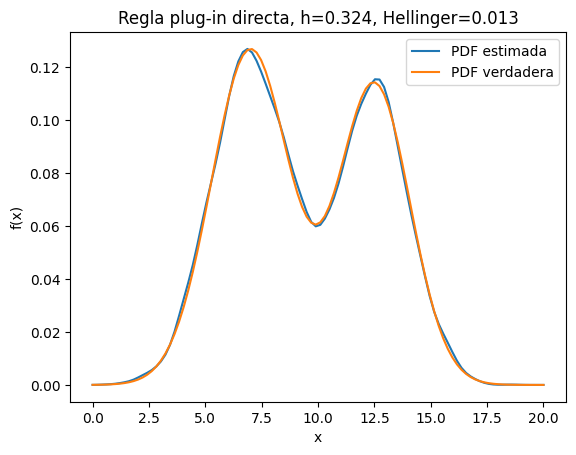

In [114]:
plt.plot(xh, fh1, xh, f)
plt.title(f"Regla plug-in directa, h={h1:.3f}, Hellinger={d1:.3f}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend(["PDF estimada", "PDF verdadera"])
plt.show()


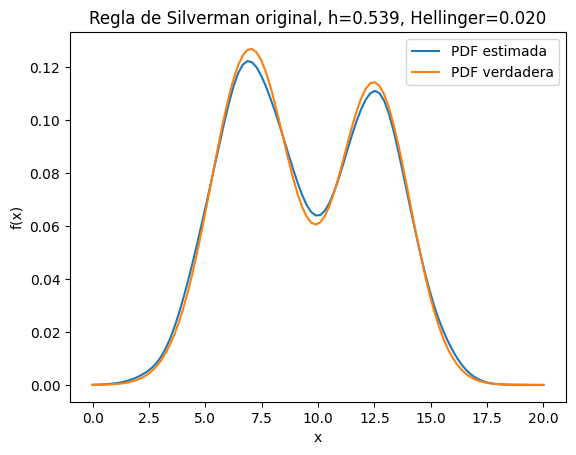

In [115]:
plt.plot(xh, fh2, xh, f)
plt.title(f"Regla de Silverman original, h={h2:.3f}, Hellinger={d2:.3f}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend(["PDF estimada", "PDF verdadera"])
plt.show()

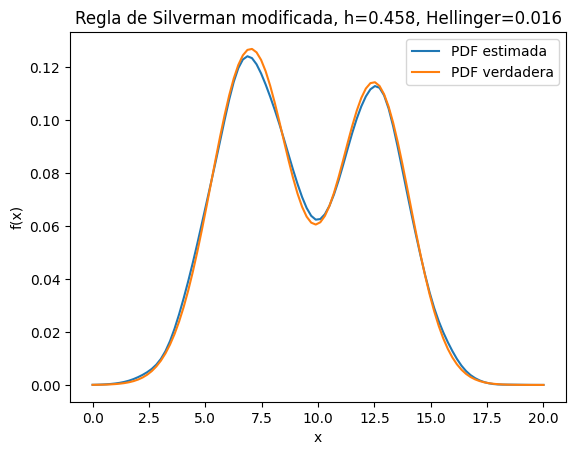

In [116]:
plt.plot(xh, fh3, xh, f)
plt.title(f"Regla de Silverman modificada, h={h3:.3f}, Hellinger={d3:.3f}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend(["PDF estimada", "PDF verdadera"])
plt.show()